# Linear decoding: shared embeddings vs GT SigLIP vs raw neural population

Using the four MultiHeadTransformer models (global/obj-crop × no-category/category-conditioned),
we extract the 512-d shared embedding for all 450 HVM stimuli and train cross-validated linear decoders for:

- **Category** (10-way classification)
- **Scale** `s` (regression)
- **Translation** `ty`, `tz` (regression)
- **Rotation** `rxy`, `rxz`, `ryz` (regression)

We compare conditions:
1. **Global neural latent** (512-d shared bottleneck, `hvm` checkpoint, no-category)
2. **Obj neural latent** (512-d shared bottleneck, `hvm_obj` checkpoint, no-category)
3. **Raw neural population** (mean-FR over time window)
4. **GT SigLIP global** (1152-d, whole-image SigLIP embedding)
5. **GT SigLIP obj-crop** (1152-d, bbox-crop SigLIP embedding)
6. **Cat-cond global neural latent** (512-d, `hvm_cat` checkpoint, category-conditioned)
7. **Cat-cond obj neural latent** (512-d, `hvm_obj_cat` checkpoint, category-conditioned)
8. **V2 given, no-cat latent** (shared_dim-d, best `hvm_v2` given checkpoint, category embedding zeroed out)

In [23]:
import sys, json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LogisticRegressionCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, r2_score
from sklearn.pipeline import Pipeline
from tqdm.notebook import tqdm

sys.path.insert(0, '.')
from config_const import (
    CACHE_DIR, SEED, HVM_N_STIMULI, HVM_N_VAR, HVM_N_CAT,
    HVM_METADATA_PATH,
    HVM_SIGLIP_EMBEDDINGS_PATH, HVM_OBJ_SIGLIP_EMBEDDINGS_PATH,
)
from data_utils.hvm_loader import _load_hvm_neural
from encoders import MultiHeadTransformer, MultiHeadTransformerV2

DEVICE = 'cpu'
GLOBAL_CKPT = Path(
    'checkpoints/multihead/hvm/'
    'd64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_'
    'bs128_ws1.0_wc1.0_uw0.1_nw0.1_nt0.07/best.pt'
)
OBJ_CKPT = Path(
    'checkpoints/multihead/hvm_obj/'
    'd64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_'
    'bs64_ws5.0_wc1.0_uw0.1_nw0.1_nt0.07/best.pt'
)
CAT_GLOBAL_CKPT = Path(
    'checkpoints/multihead/hvm_cat/'
    'd64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_'
    'bs128_ws1.0_wc1.0_uw0.1_nw0.1_nt0.07/best.pt'
)
CAT_OBJ_CKPT = Path(
    'checkpoints/multihead/hvm_obj_cat/'
    'd64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_'
    'bs64_ws5.0_wc1.0_uw0.1_nw0.1_nt0.07/best.pt'
)
# Best V2 given checkpoint (val_mean_cos = 0.9024)
V2_GIVEN_CKPT = Path(
    'checkpoints/multihead_v2/hvm_v2/'
    'd64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_'
    'bs128_wsg1.0_wso1.0_wc1.0_uw0.1_nw0.1_nt0.07_cmgiven/best.pt'
)

# Current V2 predict checkpoint. Prefer the latest no-wrong-category retrain;
# fall back to older cache names if this notebook is run before result export.
def _load_cached_ckpt(*names, fallback):
    for name in names:
        path = CACHE_DIR / name
        if path.exists():
            return Path(json.loads(path.read_text())['checkpoint'])
    return Path(fallback)

V2_PREDICT_CKPT = _load_cached_ckpt(
    'best_hvm_multihead_v2_predict_wcp0.0_config.json',
    'best_hvm_multihead_v2_predict_config.json',
    fallback=(
        'checkpoints/multihead_v2/hvm_v2/'
        'd64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_'
        'bs128_wsg1.0_wso1.0_wc1.0_uw0.1_nw0.1_nt0.07_'
        'cmpredict_cle500_clr0.001_cwd0.01_wcp0.0/best.pt'
    ),
)
print(f'V2 predict checkpoint: {V2_PREDICT_CKPT}')
N_CV_FOLDS = 5

print('Imports OK')


V2 predict checkpoint: /home/yy3658/NeurObjectGen/checkpoints/multihead_v2/hvm_v2/d64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_bs128_wsg1.0_wso1.0_wc1.0_uw0.1_nw0.1_nt0.07_cmpredict_cle500_clr0.001_cwd0.01_wcp0.0/best.pt
Imports OK


In [24]:
# ── Load metadata labels ──────────────────────────────────────────────────────
with open(HVM_METADATA_PATH) as f:
    meta = json.load(f)

meta_sorted = sorted(meta, key=lambda x: x['idx'])

CATEGORIES = ('apple','bear','car','chair','dog','elephant','head','plane','table','turtle')
cat_to_int = {c: i for i, c in enumerate(CATEGORIES)}

y_cat = np.array([cat_to_int[m['category']] for m in meta_sorted])  # (450,)
y_s   = np.array([m['s']   for m in meta_sorted])                    # scale
y_ty  = np.array([m['ty']  for m in meta_sorted])                    # y-translation
y_tz  = np.array([m['tz']  for m in meta_sorted])                    # z-translation
y_rxy = np.array([m['rxy'] for m in meta_sorted])                    # rotation xy
y_rxz = np.array([m['rxz'] for m in meta_sorted])                    # rotation xz
y_ryz = np.array([m['ryz'] for m in meta_sorted])                    # rotation yz

print(f'Labels loaded: {len(y_cat)} stimuli')
print(f'Category distribution: {np.bincount(y_cat)}')

Labels loaded: 450 stimuli
Category distribution: [45 45 45 45 45 45 45 45 45 45]


In [25]:
# ── Build raw neural feature (mean over time window) ─────────────────────────
rsp, _, _ = _load_hvm_neural()           # (450, n_neurons, T)
X_neural = rsp.mean(axis=2)              # (450, n_neurons)
print(f'Neural population shape: {X_neural.shape}')


Loading HVM sessions: 100%|██████████| 10/10 [00:03<00:00,  2.59it/s]


Neural population shape: (450, 2330)


Neurons: 2330
Metric                           Mean   Median      Max
-------------------------------------------------------
Category (ω²)                  0.0169   0.0069   0.1844
Scale (r²)                     0.0041   0.0012   0.0902
Translation ty (r²)            0.0036   0.0016   0.0901
Translation tz (r²)            0.0043   0.0014   0.1199
Rotation rxy (circ R²)         0.0057   0.0035   0.0646
Rotation rxz (circ R²)         0.0049   0.0034   0.0370
Rotation ryz (circ R²)         0.0048   0.0034   0.0425


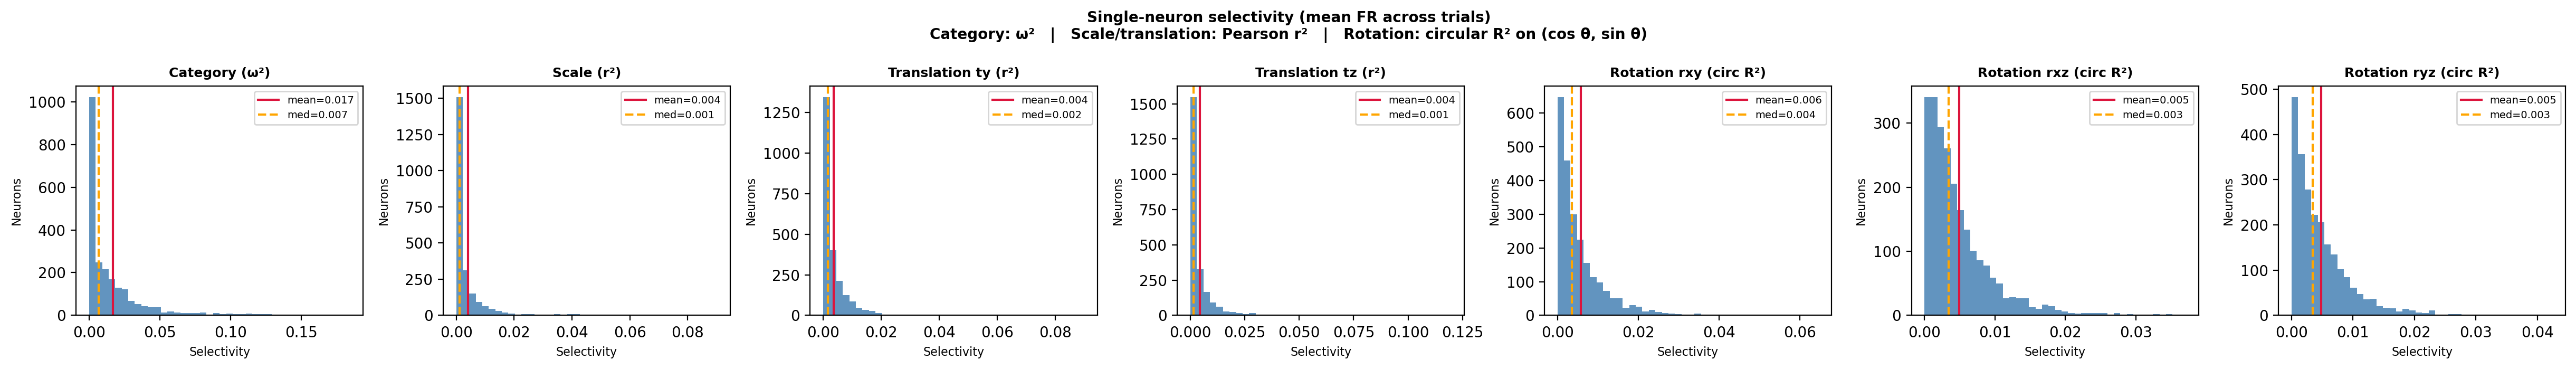

In [26]:
# ── Single-neuron selectivity ─────────────────────────────────────────────────
# Category:   omega-squared from one-way ANOVA (unbiased explained-variance)
# Linear:     Pearson r² (scale, translation)
# Circular:   R² from OLS on (cos θ, sin θ) — handles wrap-around at ±90° boundary

def omega_sq_per_neuron(X, y):
    """Omega-squared (unbiased η²) for each neuron: one-way ANOVA across y labels."""
    groups = [X[y == c] for c in np.unique(y)]
    k = len(groups)
    n = X.shape[0]
    grand = X.mean(axis=0)
    ss_between = sum(len(g) * (g.mean(axis=0) - grand)**2 for g in groups)
    ss_within  = sum(((g - g.mean(axis=0))**2).sum(axis=0) for g in groups)
    ss_total   = ss_between + ss_within
    ms_within  = ss_within / (n - k)
    omega2 = (ss_between - (k - 1) * ms_within) / (ss_total + ms_within)
    return np.clip(omega2, 0, None)

def r2_per_neuron(X, y):
    """Pearson r² between each neuron and a linear continuous label."""
    y_z = (y - y.mean()) / (y.std() + 1e-8)
    X_z = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
    return ((X_z * y_z[:, None]).mean(axis=0)) ** 2

def r2_circular_per_neuron(X, y_deg):
    """R² from OLS of each neuron onto (cos θ, sin θ) for a circular label in degrees.

    Accounts for wrap-around: a neuron tuned near ±90° gets full credit even
    though the raw degree value wraps. R² = 1 - SS_res / SS_tot.
    """
    theta = np.deg2rad(y_deg)
    C = np.stack([np.cos(theta), np.sin(theta)], axis=1)  # (N, 2)
    C = (C - C.mean(axis=0)) / (C.std(axis=0) + 1e-8)
    X_c = X - X.mean(axis=0)                              # (N, neurons)
    # OLS coefficients: beta = (C'C)^-1 C' X, shape (2, neurons)
    beta = np.linalg.lstsq(C, X_c, rcond=None)[0]
    resid = X_c - C @ beta
    ss_res = (resid**2).sum(axis=0)
    ss_tot = (X_c**2).sum(axis=0)
    return np.clip(1 - ss_res / (ss_tot + 1e-12), 0, None)

sel_cat = omega_sq_per_neuron(X_neural, y_cat)
sel_s   = r2_per_neuron(X_neural, y_s)
sel_ty  = r2_per_neuron(X_neural, y_ty)
sel_tz  = r2_per_neuron(X_neural, y_tz)
sel_rxy = r2_circular_per_neuron(X_neural, y_rxy)
sel_rxz = r2_circular_per_neuron(X_neural, y_rxz)
sel_ryz = r2_circular_per_neuron(X_neural, y_ryz)

sel_metrics = {
    'Category (ω²)':           sel_cat,
    'Scale (r²)':               sel_s,
    'Translation ty (r²)':      sel_ty,
    'Translation tz (r²)':      sel_tz,
    'Rotation rxy (circ R²)':   sel_rxy,
    'Rotation rxz (circ R²)':   sel_rxz,
    'Rotation ryz (circ R²)':   sel_ryz,
}

print(f'Neurons: {X_neural.shape[1]}')
print(f"{'Metric':<28} {'Mean':>8} {'Median':>8} {'Max':>8}")
print('-' * 55)
for name, sel in sel_metrics.items():
    print(f'{name:<28} {sel.mean():>8.4f} {np.median(sel):>8.4f} {sel.max():>8.4f}')

# ── Plot: distributions of per-neuron selectivity ────────────────────────────
n_metrics = len(sel_metrics)
fig, axes = plt.subplots(1, n_metrics, figsize=(3.5 * n_metrics, 3.5), sharey=False)

for ax, (name, sel) in zip(axes, sel_metrics.items()):
    ax.hist(sel, bins=40, color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(sel.mean(),     color='crimson', lw=1.5,        label=f'mean={sel.mean():.3f}')
    ax.axvline(np.median(sel), color='orange',  lw=1.5, ls='--', label=f'med={np.median(sel):.3f}')
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Selectivity', fontsize=8)
    ax.set_ylabel('Neurons', fontsize=8)
    ax.legend(fontsize=7)

fig.suptitle(
    'Single-neuron selectivity (mean FR across trials)\n'
    'Category: ω²   |   Scale/translation: Pearson r²   |   Rotation: circular R² on (cos θ, sin θ)',
    fontsize=10, fontweight='bold',
)
fig.tight_layout()
plt.show()

In [27]:
# ── Extract shared embeddings from all four models ───────────────────────────
def extract_embedding(ckpt_path, rsp, key, y_cat=None):
    ckpt = torch.load(ckpt_path, weights_only=False, map_location='cpu')
    args = ckpt['args']
    n_neurons_total = rsp.shape[1]
    n_cat = HVM_N_CAT if args.get('use_category', False) else 0
    model = MultiHeadTransformer(
        n_neurons   = n_neurons_total,
        d_model     = int(args['d_model']),
        n_heads     = int(args['n_heads']),
        n_layers    = int(args['n_layers']),
        shared_dim  = int(args['shared_dim']),
        dropout     = 0.0,
        n_categories= n_cat,
    )
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    neural_tensor = torch.from_numpy(rsp).float()
    cat_tensor = torch.from_numpy(y_cat).long() if y_cat is not None else None
    embeds = []
    with torch.no_grad():
        for i in range(HVM_N_STIMULI):
            x = neural_tensor[i:i+1].permute(0, 2, 1)  # (1, T, neurons)
            c = cat_tensor[i:i+1] if cat_tensor is not None else None
            embeds.append(model(x, cat=c)[key].squeeze(0).numpy())
    return np.stack(embeds)


def extract_v2_nocond(ckpt_path, rsp):
    """Extract shared from V2 given model with cat_emb zeroed (no category bias)."""
    ckpt = torch.load(ckpt_path, weights_only=False, map_location='cpu')
    args = ckpt['args']
    n_neurons_total = rsp.shape[1]
    model = MultiHeadTransformerV2(
        n_neurons   = n_neurons_total,
        d_model     = int(args['d_model']),
        n_heads     = int(args['n_heads']),
        n_layers    = int(args['n_layers']),
        shared_dim  = int(args['shared_dim']),
        dropout     = 0.0,
        n_categories= HVM_N_CAT,
    )
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    # Zero out category embedding so cat_emb(cat) contributes nothing
    with torch.no_grad():
        model.cat_emb.weight.zero_()
    neural_tensor = torch.from_numpy(rsp).float()
    dummy_cat = torch.zeros(1, dtype=torch.long)  # any index — emb is zeroed
    embeds = []
    with torch.no_grad():
        for i in range(HVM_N_STIMULI):
            x = neural_tensor[i:i+1].permute(0, 2, 1)  # (1, T, neurons)
            out = model(x, cat=dummy_cat, cat_mode='given')
            embeds.append(out['shared'].squeeze(0).numpy())
    return np.stack(embeds)


def extract_v2_predict_neural_embedding(ckpt_path, rsp):
    """Extract the current V2 predict model's no-category neural embedding.

    This deliberately uses model.encode_neural_embedding(x), not forward(...,
    cat_mode='predict'), so the representation is the neural latent before the
    predicted category embedding is retrieved and added.
    """
    ckpt = torch.load(ckpt_path, weights_only=False, map_location='cpu')
    args = ckpt['args']
    n_neurons_total = rsp.shape[1]
    model = MultiHeadTransformerV2(
        n_neurons   = n_neurons_total,
        d_model     = int(args['d_model']),
        n_heads     = int(args['n_heads']),
        n_layers    = int(args['n_layers']),
        shared_dim  = int(args['shared_dim']),
        dropout     = 0.0,
        n_categories= HVM_N_CAT,
    )
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    neural_tensor = torch.from_numpy(rsp).float()
    embeds = []
    with torch.no_grad():
        for i in range(HVM_N_STIMULI):
            x = neural_tensor[i:i+1].permute(0, 2, 1)  # (1, T, neurons)
            emb = model.encode_neural_embedding(x)
            embeds.append(emb.squeeze(0).numpy())
    return np.stack(embeds)


X_global = extract_embedding(GLOBAL_CKPT, rsp, 'shared')
print(f'Global neural latent (shared):           {X_global.shape}')

X_obj = extract_embedding(OBJ_CKPT, rsp, 'shared')
print(f'Obj neural latent (shared):              {X_obj.shape}')

# cat=None: load cat-conditioned weights but don't apply the category embedding
X_cat_global = extract_embedding(CAT_GLOBAL_CKPT, rsp, 'shared', y_cat=None)
print(f'Cat-cond global neural latent (shared):  {X_cat_global.shape}')

X_cat_obj = extract_embedding(CAT_OBJ_CKPT, rsp, 'shared', y_cat=None)
print(f'Cat-cond obj neural latent (shared):     {X_cat_obj.shape}')

X_v2_nocond = extract_v2_nocond(V2_GIVEN_CKPT, rsp)
print(f'V2 given, no-cat latent (shared):        {X_v2_nocond.shape}')

X_v2_predict = extract_v2_predict_neural_embedding(V2_PREDICT_CKPT, rsp)
print(f'V2 predict model neural embedding:       {X_v2_predict.shape}')

# ── Load GT SigLIP embeddings (global image + object crop) ───────────────────
X_siglip_global = torch.load(HVM_SIGLIP_EMBEDDINGS_PATH, weights_only=True).numpy()
print(f'GT global SigLIP embedding:              {X_siglip_global.shape}')

X_siglip_obj = torch.load(HVM_OBJ_SIGLIP_EMBEDDINGS_PATH, weights_only=True).numpy()
print(f'GT obj-crop SigLIP embedding:            {X_siglip_obj.shape}')


/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Global neural latent (shared):           (450, 512)
Obj neural latent (shared):              (450, 512)
Cat-cond global neural latent (shared):  (450, 512)
Cat-cond obj neural latent (shared):     (450, 512)
V2 given, no-cat latent (shared):        (450, 512)
V2 predict model neural embedding:       (450, 512)
GT global SigLIP embedding:              (450, 1152)
GT obj-crop SigLIP embedding:            (450, 1152)


In [28]:
# ── Cross-validated linear decoding ──────────────────────────────────────────

def decode_classification(X, y, n_folds=N_CV_FOLDS, seed=SEED):
    """Stratified k-fold logistic regression, returns per-fold accuracy."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    accs = []
    for train_idx, test_idx in tqdm(skf.split(X, y), total=n_folds, desc='folds', leave=False):
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegressionCV(
                Cs=10, cv=3, max_iter=500,
                solver='lbfgs', l1_ratios=(0,),
                use_legacy_attributes=False,
                random_state=seed, n_jobs=-1,
            )),
        ])
        pipe.fit(X[train_idx], y[train_idx])
        accs.append(accuracy_score(y[test_idx], pipe.predict(X[test_idx])))
    return np.array(accs)


def decode_regression(X, y, n_folds=N_CV_FOLDS, seed=SEED):
    """K-fold Ridge regression on a linear target, returns per-fold R²."""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    r2s = []
    for train_idx, test_idx in tqdm(kf.split(X), total=n_folds, desc='folds', leave=False):
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('reg', RidgeCV(alphas=np.logspace(-3, 5, 20))),
        ])
        pipe.fit(X[train_idx], y[train_idx])
        r2s.append(r2_score(y[test_idx], pipe.predict(X[test_idx])))
    return np.array(r2s)


def decode_regression_circular(X, y_deg, n_folds=N_CV_FOLDS, seed=SEED):
    """K-fold Ridge on (cos θ, sin θ) target, returns per-fold mean R² across both components.

    Predicting the two circular components and averaging their R² is the circular
    analogue of scalar regression R² — a neuron tuned near ±90° contributes equally
    to either component.
    """
    theta = np.deg2rad(y_deg)
    Y = np.stack([np.cos(theta), np.sin(theta)], axis=1)  # (N, 2)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    r2s = []
    for train_idx, test_idx in tqdm(kf.split(X), total=n_folds, desc='folds', leave=False):
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('reg', RidgeCV(alphas=np.logspace(-3, 5, 20))),
        ])
        pipe.fit(X[train_idx], Y[train_idx])
        r2s.append(r2_score(Y[test_idx], pipe.predict(X[test_idx]),
                            multioutput='uniform_average'))
    return np.array(r2s)



print('Decoder helpers defined')


Decoder helpers defined


In [29]:
# ── Run all decoders ──────────────────────────────────────────────────────────
linear_targets = {
    'Scale (s)':       y_s,
    'Translation ty':  y_ty,
    'Translation tz':  y_tz,
}
circular_targets = {
    'Rotation rxy':    y_rxy,
    'Rotation rxz':    y_rxz,
    'Rotation ryz':    y_ryz,
}
reg_targets = {**linear_targets, **circular_targets}

print('Category (classification) ...')
cat_global        = decode_classification(X_global,        y_cat)
cat_obj           = decode_classification(X_obj,           y_cat)
cat_neural        = decode_classification(X_neural,        y_cat)
cat_siglip_global = decode_classification(X_siglip_global, y_cat)
cat_siglip_obj    = decode_classification(X_siglip_obj,    y_cat)
cat_cat_global    = decode_classification(X_cat_global,    y_cat)
cat_cat_obj       = decode_classification(X_cat_obj,       y_cat)
cat_v2_nocond     = decode_classification(X_v2_nocond,     y_cat)
cat_v2_predict    = decode_classification(X_v2_predict,    y_cat)

reg_global, reg_obj, reg_neural = {}, {}, {}
reg_siglip_global, reg_siglip_obj = {}, {}
reg_cat_global, reg_cat_obj = {}, {}
reg_v2_nocond, reg_v2_predict = {}, {}


all_Xs = [
    (reg_neural,        X_neural),
    (reg_global,        X_global),
    (reg_obj,           X_obj),
    (reg_cat_global,    X_cat_global),
    (reg_cat_obj,       X_cat_obj),
    (reg_v2_nocond,     X_v2_nocond),
    (reg_v2_predict,    X_v2_predict),
    (reg_siglip_global, X_siglip_global),
    (reg_siglip_obj,    X_siglip_obj),
]


print('Linear regression targets ...')
for name, y in tqdm(linear_targets.items(), desc='linear'):
    for d, X in all_Xs:
        d[name] = decode_regression(X, y)

print('Circular regression targets ...')
for name, y in tqdm(circular_targets.items(), desc='circular'):
    for d, X in all_Xs:
        d[name] = decode_regression_circular(X, y)

print('Done.')


Category (classification) ...


folds:   0%|          | 0/5 [00:00<?, ?it/s]

folds:   0%|          | 0/5 [00:00<?, ?it/s]

folds:   0%|          | 0/5 [00:00<?, ?it/s]

folds:   0%|          | 0/5 [00:00<?, ?it/s]

...

folds:   0%|          | 0/5 [00:00<?, ?it/s]

folds:   0%|          | 0/5 [00:00<?, ?it/s]

folds:   0%|          | 0/5 [00:00<?, ?it/s]

folds:   0%|          | 0/5 [00:00<?, ?it/s]

Done.


In [30]:
# ── Summary table ─────────────────────────────────────────────────────────────
import pandas as pd

chance_cat = 1.0 / HVM_N_CAT

def metric_label(name):
    return 'circ R²' if name in circular_targets else ('Accuracy' if name == 'Category' else 'R²')

rows = []
rows.append(dict(
    Task='Category (accuracy)', Metric='Accuracy',
    Neural=f'{cat_neural.mean():.3f} ± {cat_neural.std():.3f}',
    Global=f'{cat_global.mean():.3f} ± {cat_global.std():.3f}',
    Obj=f'{cat_obj.mean():.3f} ± {cat_obj.std():.3f}',
    Cat_Global=f'{cat_cat_global.mean():.3f} ± {cat_cat_global.std():.3f}',
    Cat_Obj=f'{cat_cat_obj.mean():.3f} ± {cat_cat_obj.std():.3f}',
    V2_NoCond=f'{cat_v2_nocond.mean():.3f} ± {cat_v2_nocond.std():.3f}',
    V2_Predict=f'{cat_v2_predict.mean():.3f} ± {cat_v2_predict.std():.3f}',
    SigLIP_Global=f'{cat_siglip_global.mean():.3f} ± {cat_siglip_global.std():.3f}',
    SigLIP_Obj=f'{cat_siglip_obj.mean():.3f} ± {cat_siglip_obj.std():.3f}',
    Chance=f'{chance_cat:.3f}',
))
for name in reg_targets:
    rows.append(dict(
        Task=name, Metric=metric_label(name),
        Neural=f'{reg_neural[name].mean():.3f} ± {reg_neural[name].std():.3f}',
        Global=f'{reg_global[name].mean():.3f} ± {reg_global[name].std():.3f}',
        Obj=f'{reg_obj[name].mean():.3f} ± {reg_obj[name].std():.3f}',
        Cat_Global=f'{reg_cat_global[name].mean():.3f} ± {reg_cat_global[name].std():.3f}',
        Cat_Obj=f'{reg_cat_obj[name].mean():.3f} ± {reg_cat_obj[name].std():.3f}',
        V2_NoCond=f'{reg_v2_nocond[name].mean():.3f} ± {reg_v2_nocond[name].std():.3f}',
        V2_Predict=f'{reg_v2_predict[name].mean():.3f} ± {reg_v2_predict[name].std():.3f}',
        SigLIP_Global=f'{reg_siglip_global[name].mean():.3f} ± {reg_siglip_global[name].std():.3f}',
        SigLIP_Obj=f'{reg_siglip_obj[name].mean():.3f} ± {reg_siglip_obj[name].std():.3f}',
        Chance='0.000',
    ))

df = pd.DataFrame(rows).set_index('Task')
print(df.to_string())


                       Metric          Neural          Global             Obj      Cat_Global         Cat_Obj       V2_NoCond      V2_Predict   SigLIP_Global      SigLIP_Obj Chance
Task                                                                                                                                                                                
Category (accuracy)  Accuracy   0.444 ± 0.048   0.318 ± 0.040   0.300 ± 0.040   0.607 ± 0.033   0.542 ± 0.023   0.569 ± 0.025   0.551 ± 0.041   0.944 ± 0.026   0.971 ± 0.018  0.100
Scale (s)                  R²   0.041 ± 0.038   0.017 ± 0.032   0.030 ± 0.022   0.003 ± 0.042   0.106 ± 0.059   0.020 ± 0.040   0.028 ± 0.030   0.349 ± 0.045   0.486 ± 0.097  0.000
Translation ty             R²   0.059 ± 0.073  -0.007 ± 0.046  -0.006 ± 0.048  -0.024 ± 0.054  -0.038 ± 0.039  -0.002 ± 0.052   0.002 ± 0.046  -0.029 ± 0.023  -0.026 ± 0.026  0.000
Translation tz             R²   0.165 ± 0.087   0.097 ± 0.053   0.091 ± 0.072   0.079 ± 0.055  

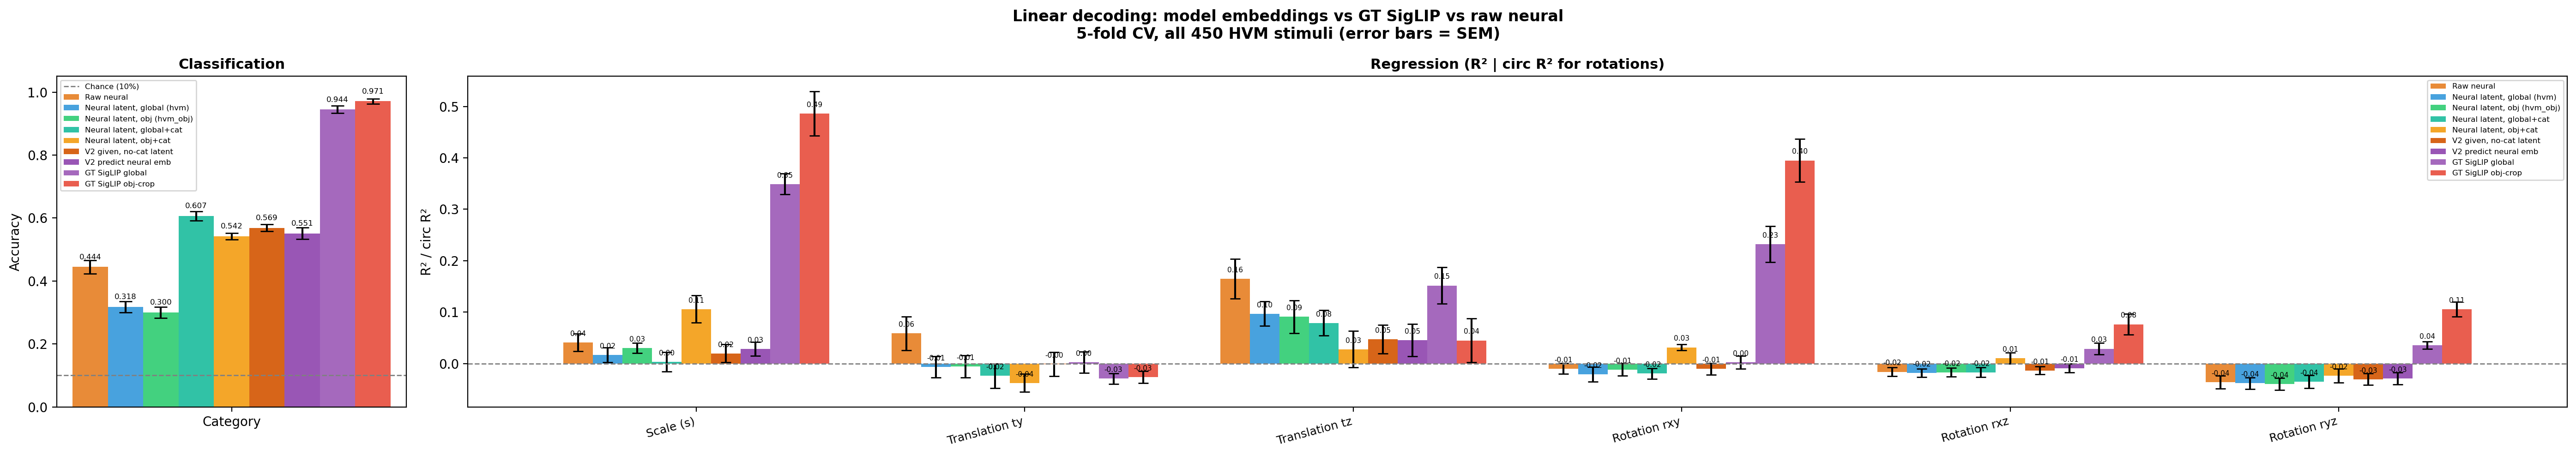

In [31]:
# ── Plot: grouped bar chart ──────────────────────────────────────────────────
all_task_names = ['Category'] + list(reg_targets.keys())

color_global        = '#3498db'
color_obj           = '#2ecc71'
color_neural        = '#e67e22'
color_siglip_global = '#9b59b6'
color_siglip_obj    = '#e74c3c'
color_cat_global    = '#1abc9c'
color_cat_obj       = '#f39c12'
color_v2_nocond     = '#d35400'
color_v2_predict    = '#8e44ad'
width = 0.09

def sem(a): return a.std() / np.sqrt(len(a))

CONDITIONS = [
    (-4*width, cat_neural,        reg_neural,        color_neural,        'Raw neural'),
    (-3*width, cat_global,        reg_global,        color_global,        'Neural latent, global (hvm)'),
    (-2*width, cat_obj,           reg_obj,           color_obj,           'Neural latent, obj (hvm_obj)'),
    (-1*width, cat_cat_global,    reg_cat_global,    color_cat_global,    'Neural latent, global+cat'),
    ( 0*width, cat_cat_obj,       reg_cat_obj,       color_cat_obj,       'Neural latent, obj+cat'),
    (+1*width, cat_v2_nocond,     reg_v2_nocond,     color_v2_nocond,     'V2 given, no-cat latent'),
    (+2*width, cat_v2_predict,    reg_v2_predict,    color_v2_predict,    'V2 predict neural emb'),
    (+3*width, cat_siglip_global, reg_siglip_global, color_siglip_global, 'GT SigLIP global'),
    (+4*width, cat_siglip_obj,    reg_siglip_obj,    color_siglip_obj,    'GT SigLIP obj-crop'),
]

fig, axes = plt.subplots(1, 2, figsize=(28, 5),
                         gridspec_kw={'width_ratios': [1, 6]})

# ---- left: category ----
ax0 = axes[0]
for offset, cat_res, _, color, label in CONDITIONS:
    m, e = cat_res.mean(), sem(cat_res)
    ax0.bar(offset, m, width, yerr=e, color=color, capsize=5, alpha=0.9, label=label)
    ax0.text(offset, m + 0.02, f'{m:.3f}', ha='center', va='bottom', fontsize=6)
ax0.axhline(chance_cat, color='grey', ls='--', lw=1, label='Chance (10%)')
ax0.set_xticks([0]); ax0.set_xticklabels(['Category'], fontsize=10)
ax0.set_ylabel('Accuracy', fontsize=10); ax0.set_ylim(0, 1.05)
ax0.set_title('Classification', fontweight='bold', fontsize=11)
ax0.legend(fontsize=6)

# ---- right: regression ----
ax1 = axes[1]
reg_names = list(reg_targets.keys())
r_x = np.arange(len(reg_names))

for offset, _, reg_res, color, label in CONDITIONS:
    means = np.array([reg_res[n].mean() for n in reg_names])
    errs  = np.array([sem(reg_res[n])   for n in reg_names])
    ax1.bar(r_x + offset, means, width, yerr=errs, color=color, capsize=4, alpha=0.9, label=label)
    for x_pos, v in zip(r_x + offset, means):
        ax1.text(x_pos, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=5.5)

ax1.axhline(0, color='grey', ls='--', lw=1)
ax1.set_xticks(r_x); ax1.set_xticklabels(reg_names, fontsize=9, rotation=15, ha='right')
ax1.set_ylabel('R² / circ R²', fontsize=10)
ax1.set_title('Regression (R² | circ R² for rotations)', fontweight='bold', fontsize=11)
ax1.legend(fontsize=6)

fig.suptitle(
    f'Linear decoding: model embeddings vs GT SigLIP vs raw neural\n'
    f'{N_CV_FOLDS}-fold CV, all 450 HVM stimuli (error bars = SEM)',
    fontsize=12, fontweight='bold',
)
fig.tight_layout()
plt.show()


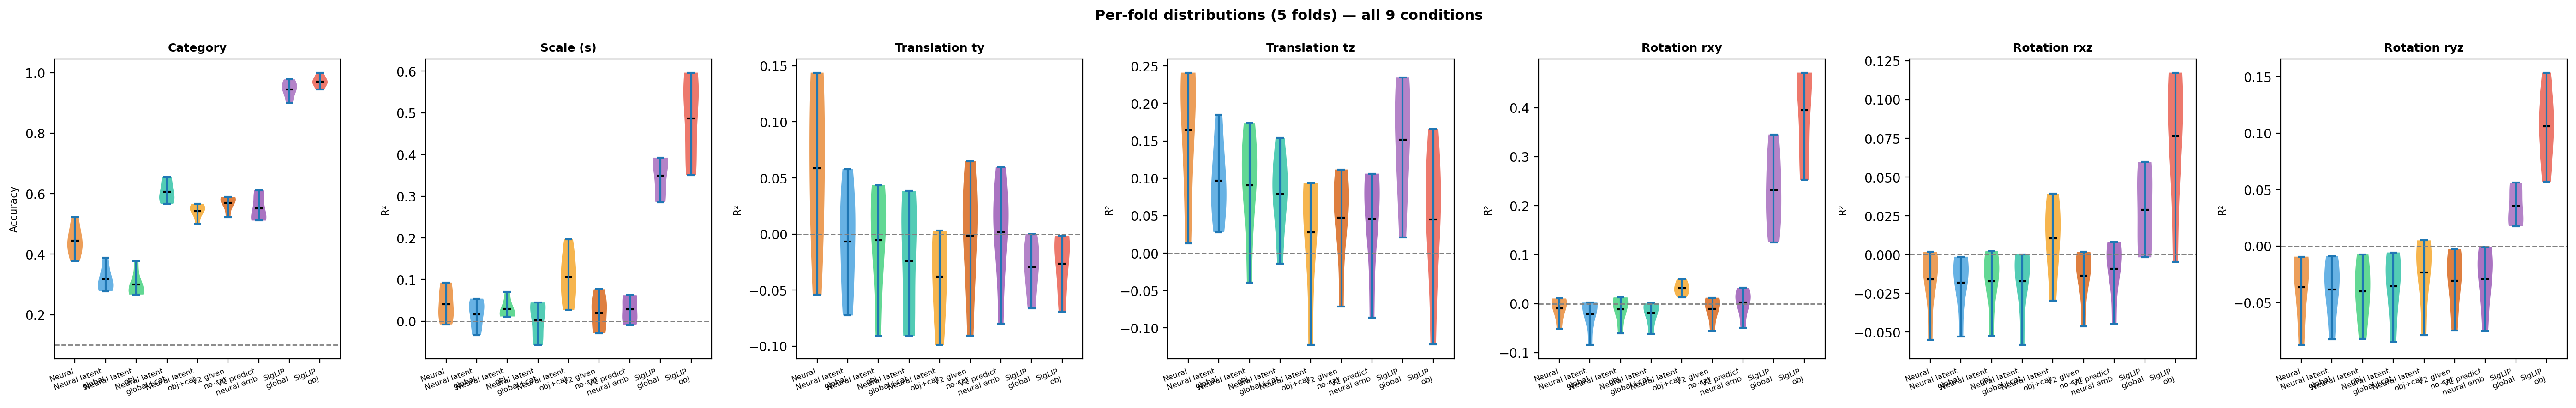

In [32]:
# ── Per-fold detail (violin plot) ────────────────────────────────────────────
n_tasks = len(all_task_names)
fig2, axes2 = plt.subplots(1, n_tasks, figsize=(4 * n_tasks, 4.5), sharey=False)

fold_data = {
    'Neural':          ([cat_neural]        + [reg_neural[n]        for n in reg_targets], color_neural),
    'Neural latent\nglobal': ([cat_global]  + [reg_global[n]        for n in reg_targets], color_global),
    'Neural latent\nobj':    ([cat_obj]     + [reg_obj[n]           for n in reg_targets], color_obj),
    'Neural latent\nglobal+cat': ([cat_cat_global] + [reg_cat_global[n] for n in reg_targets], color_cat_global),
    'Neural latent\nobj+cat':   ([cat_cat_obj]    + [reg_cat_obj[n]    for n in reg_targets], color_cat_obj),
    'V2 given\nno-cat':    ([cat_v2_nocond] + [reg_v2_nocond[n]     for n in reg_targets], color_v2_nocond),
    'V2 predict\nneural emb': ([cat_v2_predict] + [reg_v2_predict[n] for n in reg_targets], color_v2_predict),
    'SigLIP\nglobal':  ([cat_siglip_global] + [reg_siglip_global[n] for n in reg_targets], color_siglip_global),
    'SigLIP\nobj':     ([cat_siglip_obj]    + [reg_siglip_obj[n]    for n in reg_targets], color_siglip_obj),
}
positions = list(range(1, len(fold_data) + 1))
ylabels = ['Accuracy'] + ['R²'] * len(reg_targets)

for ax, task_idx, name, ylabel in zip(axes2, range(n_tasks), all_task_names, ylabels):
    data_per_cond = [fold_data[k][0][task_idx] for k in fold_data]
    colors        = [fold_data[k][1]           for k in fold_data]
    vp = ax.violinplot(data_per_cond, positions=positions, showmeans=True, showextrema=True)
    for body, color in zip(vp['bodies'], colors):
        body.set_facecolor(color); body.set_alpha(0.75)
    vp['cmeans'].set_color('black')
    ax.set_xticks(positions)
    ax.set_xticklabels(list(fold_data.keys()), fontsize=6, rotation=20, ha='right')
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.axhline(chance_cat if name == 'Category' else 0, color='grey', ls='--', lw=1)

fig2.suptitle(
    f'Per-fold distributions ({N_CV_FOLDS} folds) — all 9 conditions',
    fontsize=11, fontweight='bold',
)
fig2.tight_layout()
plt.show()
